# Illustrate edge effects seen in CWT amplitude spectrogram

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
import wavelet_funcs as wf

path.append('../signals/')
import signals as sg

path.append('../../')
import superlet as st

In [5]:
from scipy.signal import periodogram

# CWT

### Perfect cyclic cosine

In [13]:
fs = 100
t,s = sg.cosine(10, 2, fs)

# ndrop = 12

# t = t[:-ndrop]
# s = s[:-ndrop]


(<Figure size 1200x700 with 2 Axes>,
 (<Axes: ylabel='Contrast (dim. less)'>,
  <Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>))

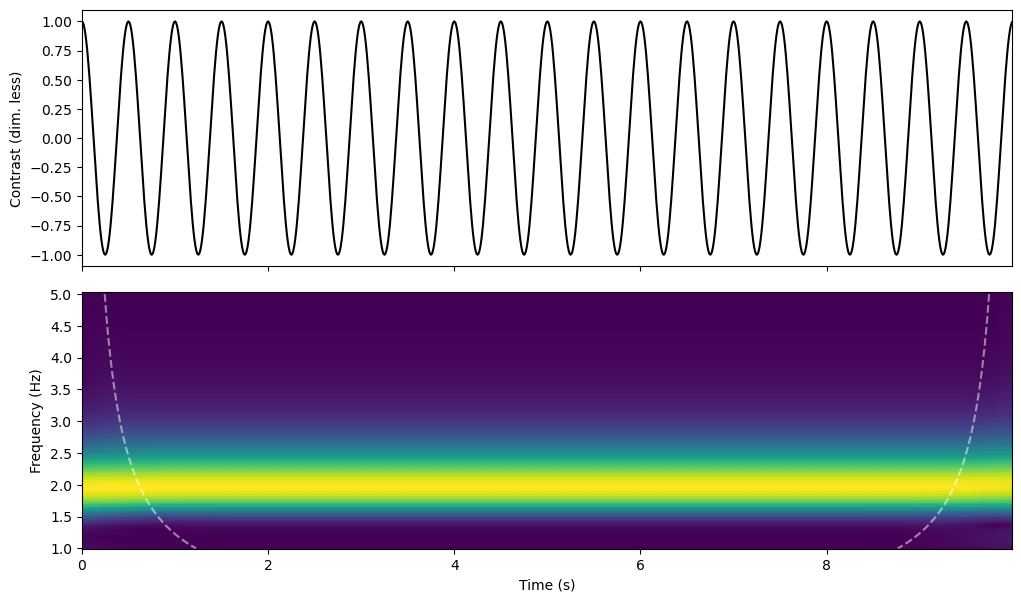

In [14]:
wf.plot_timeseries_and_its_cwt(s, t, f1=1, f2=5, method='fft', show_smoothed=False)

### Cosine with a phase shift in the middle

In [62]:
t,s = sg.cosine(10, 2, fs)
t_shift = 4

ndrop = 25
s_ = s[t>t_shift][ndrop:]
s = np.concatenate((s[t<t_shift], s_))
t = np.arange(s.size)*np.diff(t)[0]



Text(0.5, 1.0, 'Central_frequency = 1 Hz, Bandwidth=1.5 s^2')

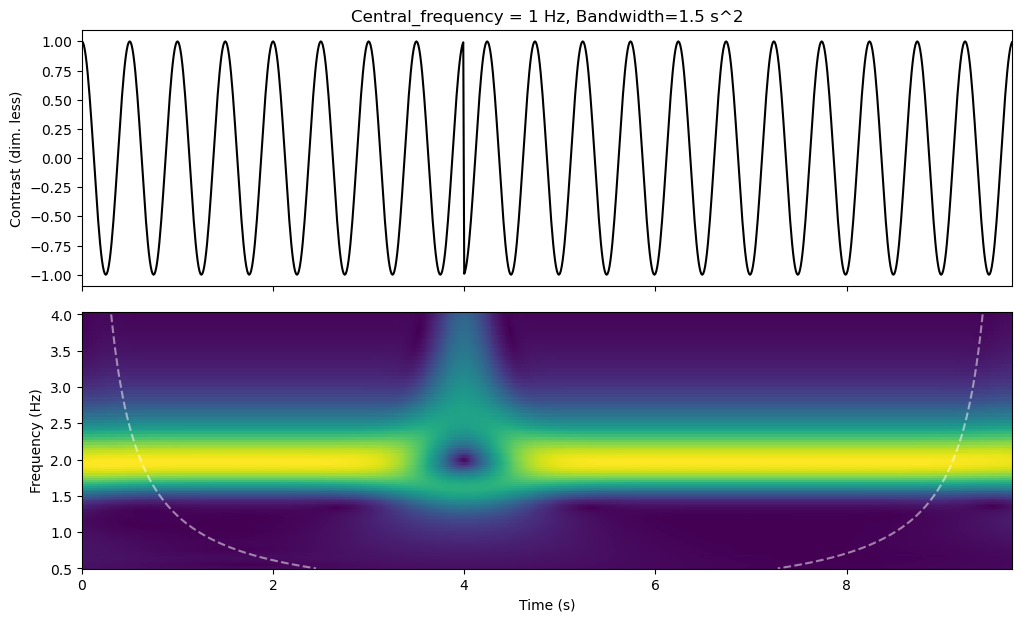

In [63]:
_, (ax, _) = wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', central_freq=1, show_smoothed=False)
ax.set_title('Central_frequency = 1 Hz, Bandwidth=1.5 s^2')

# Superlet transform

In [11]:
s.size

974

In [64]:
suplet = st.SuperletTransform(inputSize=s.size, 
                     samplingRate=fs, 
                     frequencyRange=(0.5,4),
                     frequencyBins=200,
                     baseCycles=5,
                     superletOrders=(1,5)
                    )

suplet.coefs = suplet.transform(s)

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

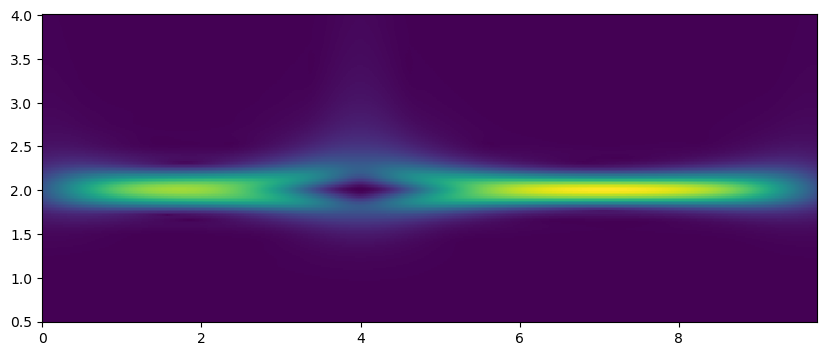

In [65]:
wf.plot_cwt(suplet.coefs, suplet.frequencies, t)

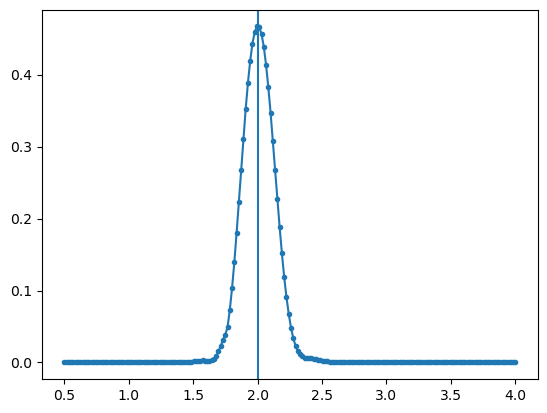

In [66]:
plt.plot(suplet.frequencies, suplet.coefs[:, (t>6)&(t<8)].mean(axis=1), '.-')
plt.axvline(2)
# plt.xlim(1.9,2.1)
# plt.ylim(0.25,0.31)

# With noise

In [72]:
t,s = sg.cosine(10, 2, fs)
s += np.random.randn(s.size)*2
t_shift = 4

ndrop = 25
s_ = s[t>t_shift][ndrop:]
s = np.concatenate((s[t<t_shift], s_))
t = np.arange(s.size)*np.diff(t)[0]



Text(0.5, 1.0, 'Central_frequency = 1 Hz, Bandwidth=1.5 s^2')

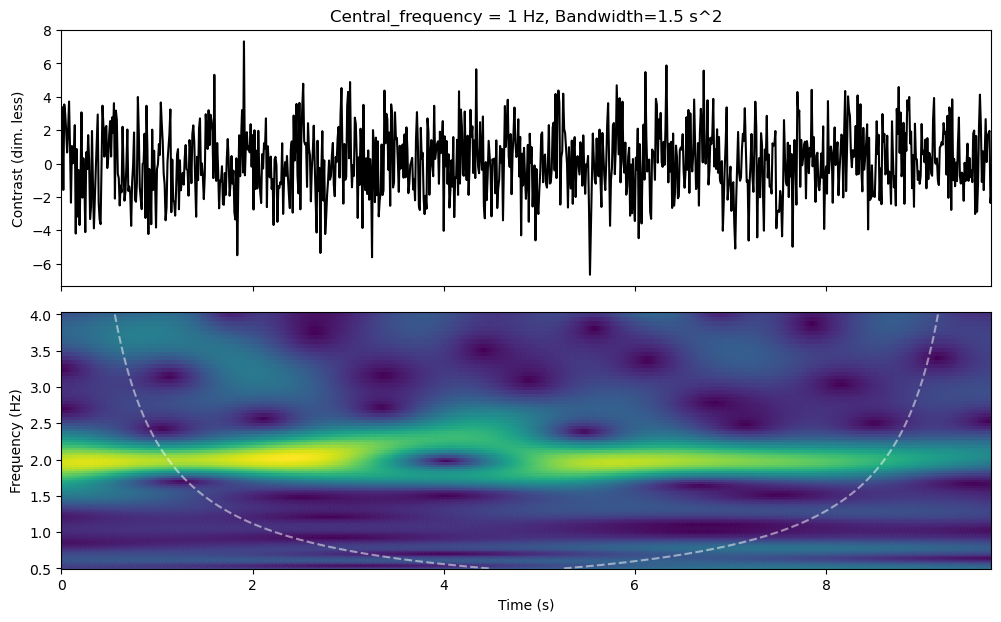

In [84]:
_, (ax, _) = wf.plot_timeseries_and_its_cwt(s, t, f1=0.5, f2=4, method='fft', central_freq=1, bandwidth=5, show_smoothed=False)
ax.set_title('Central_frequency = 1 Hz, Bandwidth=1.5 s^2')

# Superlet transform

In [85]:
suplet = st.SuperletTransform(inputSize=s.size, 
                     samplingRate=fs, 
                     frequencyRange=(0.5,4),
                     frequencyBins=200,
                     baseCycles=5,
                     superletOrders=(1,5)
                    )

suplet.coefs = suplet.transform(s)

(<Figure size 1000x400 with 1 Axes>, <Axes: >)

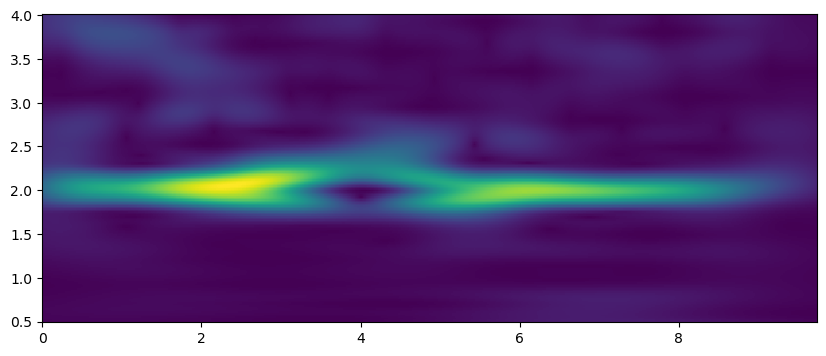

In [86]:
wf.plot_cwt(suplet.coefs, suplet.frequencies, t)

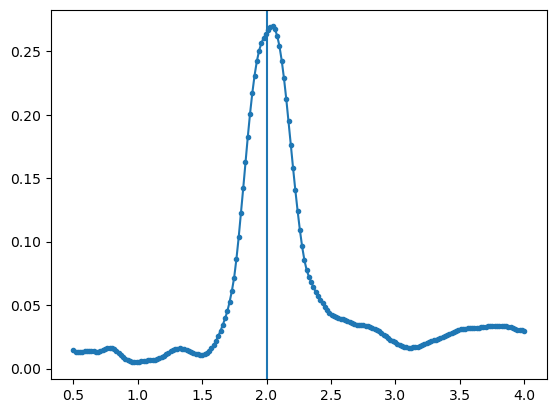

In [87]:
plt.plot(suplet.frequencies, suplet.coefs.mean(axis=1), '.-')
plt.axvline(2)
# plt.xlim(1.9,2.1)
# plt.ylim(0.25,0.31)